In [30]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib
# matplotlib.use("Agg") #figures¯ are not sent to the Jupyter frontend #*#* (turn off if wanting to see plots in Notebook)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [31]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [32]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    # print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [33]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [34]:
################################################################################

In [35]:
#DATA DESCRIPTIONS

### Data Type
# MicroPulse Differential Absorption Lidar (MPD)

### DOI (Permanent Link)
# https://doi.org/10.26023/QA4M-CDHH-MY0Z

### Summary
# MicroPulse Differential Absorption Lidar (MPD) data 
# in NetCDF format which were collected during the 
# Prediction of Rainfall Extremes Campaign In the Pacific (PRECIP). 
# Three MPDs were deployed to Taiwan for this field project.

### Temporal Coverage
# Begin datetime	2022-05-25 00:00:00
# End datetime	2022-08-11 02:59:59

### Spatial Coverage
# Maximum (North) Latitude: 27.50, Minimum (South) Latitude: 22.50
# Minimum (West) Longitude: 118.00, Maximum (East) Longitude: 123.50

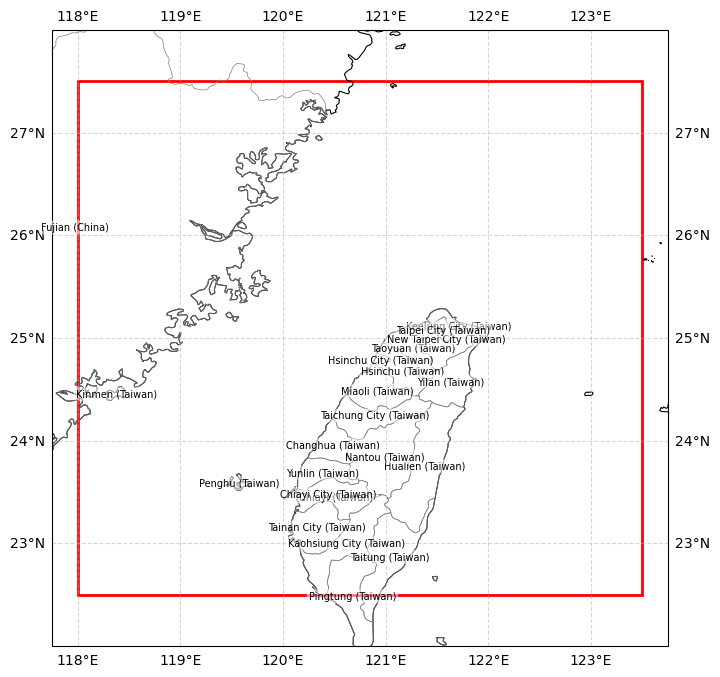

In [36]:
mapPlotting = MapPlotting(
    sw_corner=(22.50, 118.00),  # (lat_min, lon_min)
    ne_corner=(27.50, 123.50),  # (lat_max, lon_max)
    delta=3,
    fontsize=7
)
mapPlotting.PlotBoundingBox()

In [37]:
################################################################################

In [69]:
#SET UP DIRECTORIES
Campaign="PRECIP"
DataType="NCAR_SPol_RadarMoments_Data"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

def GetDataDirectory(Campaign, Downloaded_File,
                     DataType="NCAR_SPol_RadarMoments_Data",
                     RadarType='SUR',
                     BaseDir="/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"):
    #old base directory: BaseDir="/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
    SurDir = os.path.join(BaseDir, Campaign, DataType, Downloaded_File, "unzip", RadarType.lower()) 
    #SUR is the same as PPI (Plan Position Indicator) radar, RHI is Range-Height-Indicator
    Date = os.listdir(SurDir)[0]
    Data_Directory = os.path.join(SurDir, Date)
    print("Data Directory Set as:", Data_Directory, '\n')
    FileList = ListFiles(Data_Directory)
    return Data_Directory, FileList
# Downloaded_File="abrah3490212"
# Data_Directory, FileList=GetDataDirectory(Campaign, Downloaded_File,RadarType="SUR")

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/PRECIP 



In [39]:
#READING DATA
###################################
#how to unzip in terminal
# mkdir -p unzip
# for f in *.tar; do
#     tar -xvf "$f" -C unzip
# done

In [40]:
def GetData(Data_Directory, FileList, index):
    DataFile = os.path.join(Data_Directory,FileList[index])
    # print(f"Downloading File:\n {DataFile}","\n")
    DataNC = xr.open_dataset(DataFile,decode_timedelta=True)
    return DataNC, DataFile

In [41]:
#PLOTTING FUNCTIONS
###################################

In [48]:
#GETTING COLORMAPS

# The Python ARM Radar Toolkit - Py-ART
# git clone https://github.com/ProjectPythia/radar-cookbook.git
# pip install arm_pyart
import pyart

import inspect
print(inspect.getsource(pyart.config.get_field_colormap))
print(pyart.config._DEFAULT_FIELD_COLORMAP.keys())


cmap_reflectivity = pyart.config.get_field_colormap('reflectivity')
# cmap_dBZ = pyart.config.get_field_colormap('dBZ') #same as reflectivity
# cmap_dbz = pyart.config.get_field_colormap('dbz') #same as reflectivity
# cmap_DBZ = pyart.config.get_field_colormap('DBZ') #same as reflectivity
cmap_viridis = plt.cm.viridis
cmap_velocity = pyart.config.get_field_colormap('velocity')
cmap_inferno = plt.cm.inferno
# import matplotlib.cm as cm
# cmap = cm.get_cmap(cmap_reflectivity)
# cmap

def get_field_colormap(field):
    """
    Return the colormap name from the configuration file for a field name.
    """
    if field in _DEFAULT_FIELD_COLORMAP:
        return _DEFAULT_FIELD_COLORMAP[field]
    else:
        import matplotlib

        # Use the default matplotlib colormap
        return matplotlib.colormaps.get_cmap("Spectral_r").name

dict_keys(['reflectivity', 'corrected_reflectivity', 'total_power', 'signal_to_noise_ratio', 'velocity', 'corrected_velocity', 'simulated_velocity', 'eastward_wind_component', 'northward_wind_component', 'vertical_wind_component', 'spectrum_width', 'normalized_coherent_power', 'differential_reflectivity', 'corrected_differential_reflectivity', 'clutter_filter_power_removed', 'cross_correlation_ratio', 'logarithmic_cross_correlation_ratio', 'differential_phase', 'unfolded_differential_phase', 'corrected_differential_phase', 'specific_differential_phase', 'corrected_specific_differential_phase', 'linear_polarization_ratio', 'linear_depol

In [49]:
def GetSavePath(DataDate, OutputFolder, StartTime, EndTime):
    
    # Convert StartTime and EndTime to safe filename strings
    def clean_time(t): return t.replace(":", "_")
    
    StartTime_clean = clean_time(StartTime)  # e.g., "203646127"
    EndTime_clean = clean_time(EndTime)      # e.g., "204246399"
    
    # Build output path
    OutputName = f"{StartTime_clean}_to_{EndTime_clean}.jpg"
    SavePath = os.path.join(Output_Directory, OutputFolder, DataDate)

    return SavePath, OutputName

In [71]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

class RadarScan_PPI:
    def __init__(self, data_directory, file_list, index=1):
        self.DataNC, self.DataFile = GetData(data_directory, file_list, index)
        self.DataName = os.path.basename(self.DataFile)
        
        self.DataDate = self._extract_date_from_filename(self.DataName)
        self.TimeRange = self._extract_time_range_from_filename(self.DataName)
        self.TimeTitle = self._format_time_title("start")

        self._extract_metadata()
        self._extract_variables()
        self._compute_cartesian()
        self._compute_latlon()

        # Close NetCDF
        self.DataNC.close()

    # ----------------------------------------------------
    # Utilities
    # ----------------------------------------------------
    def _extract_date_from_filename(self, filename):
        match = re.search(r'\d{8}', filename)
        return match.group(0) if match else None

    def _extract_time_range_from_filename(self, filename):
        matches = re.findall(r'(\d{8})_(\d{2})(\d{2})(\d{2})\.(\d{3})', filename)
        if len(matches) >= 2:
            start = f"{matches[0][0]}_{matches[0][1]}:{matches[0][2]}:{matches[0][3]}.{matches[0][4]}"
            end   = f"{matches[1][0]}_{matches[1][1]}:{matches[1][2]}:{matches[1][3]}.{matches[1][4]}"
            return start, end
        return None, None

    def _format_time_title(self, which="start"):
        from datetime import datetime
        if not self.TimeRange or not self.TimeRange[0]:
            return "Time Unknown"

        tstr = self.TimeRange[0] if which == "start" else self.TimeRange[1]
        try:
            dt = datetime.strptime(tstr, "%Y%m%d_%H:%M:%S.%f")
            return dt.strftime("%Y/%m/%d %H:%M:%S UTC")
        except ValueError:
            return tstr

    def _extract_metadata(self):
        self.radar_longitude = self.DataNC['longitude'].values
        self.radar_latitude = self.DataNC['latitude'].values
        self.nt = self.DataNC.sizes['time']
        self.nr = self.DataNC.sizes['range']
        self.times = self.DataNC['time']
        self.azimuths = self.DataNC['azimuth'].values
        self.ranges = (
            self.DataNC['ray_start_range'][0].values +
            np.arange(self.nr) * self.DataNC['ray_gate_spacing'][0].values
        )

    def _extract_variables(self):
        self.dbz = self.DataNC['DBZ'].values.reshape(self.nt, self.nr)
        self.vel = self.DataNC['VEL'].values.reshape(self.nt, self.nr)

    def _compute_cartesian(self):
        r, theta = np.meshgrid(self.ranges, np.deg2rad(self.azimuths))
        self.x = r * np.sin(theta)
        self.y = r * np.cos(theta)

    def _compute_latlon(self):
        R = 6.371e6
        dLat = (self.y / R) * (180 / np.pi)
        dLon = (self.x / (R * np.cos(np.deg2rad(self.radar_latitude)))) * (180 / np.pi)
        self.Latitude = self.radar_latitude + dLat
        self.Longitude = self.radar_longitude + dLon

    def summary(self):
        print(f"Radar file: {self.DataName}")
        print(f"Radar date: {self.DataDate}")
        print(f"Time range: {self.TimeRange[0]} to {self.TimeRange[1]}")
        print(f"Radar location: ({self.radar_latitude:.4f}, {self.radar_longitude:.4f})")
        print(f"Shape of reflectivity (dbz): {self.dbz.shape}")
        print(f"Computed lat/lon grid: {self.Latitude.shape}")

    # ----------------------------------------------------
    # Plotting methods
    # ----------------------------------------------------
    def plot_reflectivity(self, cmap_reflectivity, plotter, OutputFolder="RadarReflectivity"):
        fig, ax = plotter.PlotFromBounds(
            lat_min=self.Latitude.min(), lat_max=self.Latitude.max(),
            lon_min=self.Longitude.min(), lon_max=self.Longitude.max()
        )
        cs = ax.contourf(self.Longitude, self.Latitude, self.dbz, cmap=cmap_reflectivity)
        plt.colorbar(cs, ax=ax, label="Reflectivity (dBZ)")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_aspect("equal")
        ax.plot(self.radar_longitude, self.radar_latitude, "o", color="black", markersize=12)
        ax.set_title(self.TimeTitle, fontsize=18, fontweight="bold")

        # SavePath, OutputName = GetSavePath(
        #     DataDate=self.DataDate, OutputFolder=OutputFolder,
        #     StartTime=self.TimeRange[0], EndTime=self.TimeRange[1]
        # )
        # os.makedirs(SavePath, exist_ok=True)
        # FullOutputFile = os.path.join(SavePath, OutputName)
        # plt.savefig(FullOutputFile, dpi=150, bbox_inches="tight")
        # plt.close(fig)
        # print(f"Saved reflectivity figure to: {FullOutputFile}")
        # return FullOutputFile

    def plot_velocity(self, cmap_velocity, plotter, OutputFolder="RadialVelocity"):
        fig, ax = plotter.PlotFromBounds(
            lat_min=self.Latitude.min(), lat_max=self.Latitude.max(),
            lon_min=self.Longitude.min(), lon_max=self.Longitude.max()
        )
        cs = ax.contourf(self.Longitude, self.Latitude, self.vel, cmap=cmap_velocity)
        plt.colorbar(cs, ax=ax, label="Radial Velocity (m/s)")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_aspect("equal")
        ax.plot(self.radar_longitude, self.radar_latitude, "o", color="black", markersize=12)
        ax.set_title(self.TimeTitle, fontsize=18, fontweight="bold")

        # SavePath, OutputName = GetSavePath(
        #     DataDate=self.DataDate, OutputFolder=OutputFolder,
        #     StartTime=self.TimeRange[0], EndTime=self.TimeRange[1]
        # )
        # os.makedirs(SavePath, exist_ok=True)
        # FullOutputFile = os.path.join(SavePath, OutputName)
        # plt.savefig(FullOutputFile, dpi=150, bbox_inches="tight")
        # plt.close(fig)
        # print(f"Saved velocity figure to: {FullOutputFile}")
        # return FullOutputFile


Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/NCAR_SPol_RadarMoments_Data/abrah3490212/unzip/sur/20220527 

Radar file: cfrad.20220527_021246.035_to_20220527_021846.379_SPOL_PrecipSur1_SUR.nc
Radar date: 20220527
Time range: 20220527_02:12:46.035 to 20220527_02:18:46.379
Radar location: (24.8191, 120.9075)
Shape of reflectivity (dbz): (4800, 1999)
Computed lat/lon grid: (4800, 1999)


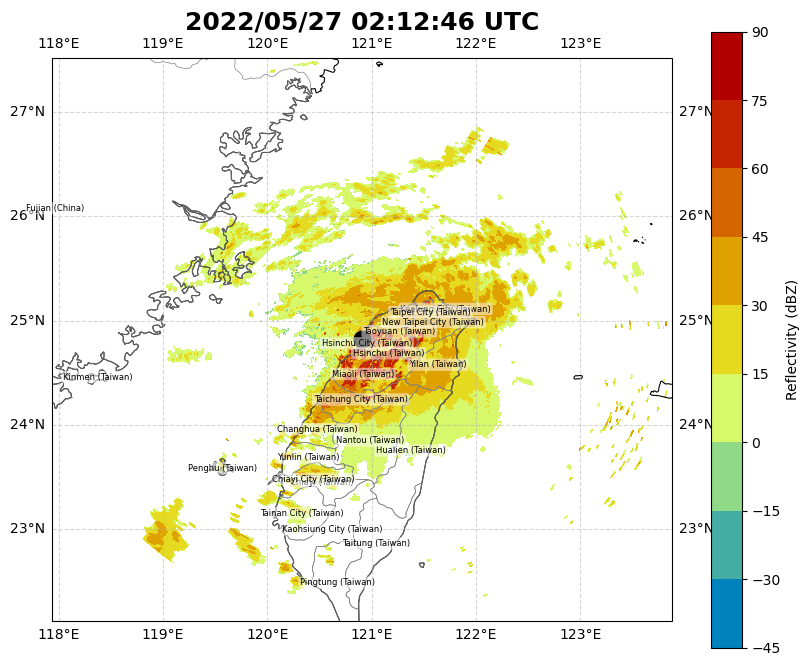

In [72]:
# 1. Setup
Downloaded_Files = [
    "abrah3490212", "abrah3490427", "abrah3490662", "abrah3490787",
    "abrah3490851", "abrah3490958", "abrah3491051", "abrah3491164",
    "abrah3491407", "abrah3491539", "abrah3491655", "abrah3491774",
    "abrah3492007", "abrah3538738", "abrah3545842", "abrah3546228",
    "abrah3547913", "abrah3548220", "abrah3548825",
]
Downloaded_File = Downloaded_Files[0]
Data_Directory, FileList=GetDataDirectory(Campaign, Downloaded_File,RadarType="SUR")

# #Map Plotter
# plotter=MapPlotting(fontsize=6)

radar = RadarScan_PPI(Data_Directory, FileList, index=0)
radar.summary()

# Map plotter instance
plotter = MapPlotting(fontsize=6)

# 2. Plot reflectivity
radar.plot_reflectivity(cmap_reflectivity=cmap_reflectivity, plotter=plotter)

# # 3. Plot velocity
# radar.plot_velocity(cmap_velocity=cmap_velocity, plotter=plotter)


In [90]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

class RadarScan_RHI:
    def __init__(self, data_directory, file_list, index=1):
        self.DataNC, self.DataFile = GetData(data_directory, file_list, index)
        self.DataName = os.path.basename(self.DataFile)
        
        self.DataDate = self._extract_date_from_filename(self.DataName)
        self.TimeRange = self._extract_time_range_from_filename(self.DataName)
        self.TimeTitle = self._format_time_title("start")

        self._extract_metadata()
        self._extract_variables()
        self._compute_cartesian()
        self._compute_latlon()

        # Close NetCDF
        self.DataNC.close()

    # ----------------------------------------------------
    # Utilities (same as before)
    # ----------------------------------------------------
    def _extract_date_from_filename(self, filename):
        match = re.search(r'\d{8}', filename)
        return match.group(0) if match else None

    def _extract_time_range_from_filename(self, filename):
        matches = re.findall(r'(\d{8})_(\d{2})(\d{2})(\d{2})\.(\d{3})', filename)
        if len(matches) >= 2:
            start = f"{matches[0][0]}_{matches[0][1]}:{matches[0][2]}:{matches[0][3]}.{matches[0][4]}"
            end   = f"{matches[1][0]}_{matches[1][1]}:{matches[1][2]}:{matches[1][3]}.{matches[1][4]}"
            return start, end
        return None, None

    def _format_time_title(self, which="start"):
        from datetime import datetime
        if not self.TimeRange or not self.TimeRange[0]:
            return "Time Unknown"

        tstr = self.TimeRange[0] if which == "start" else self.TimeRange[1]
        try:
            dt = datetime.strptime(tstr, "%Y%m%d_%H:%M:%S.%f")
            return dt.strftime("%Y/%m/%d %H:%M:%S UTC")
        except ValueError:
            return tstr

    # ----------------------------------------------------
    # Metadata & Variables
    # ----------------------------------------------------
    def _extract_metadata(self):
        self.radar_longitude = self.DataNC['longitude'].values
        self.radar_latitude = self.DataNC['latitude'].values
        self.nt = self.DataNC.sizes['time']
        self.nr = self.DataNC.sizes['range']
        self.times = self.DataNC['time']
        self.elevations = self.DataNC['elevation'].values
        self.azimuth = float(self.DataNC['azimuth'][0].values)  # fixed azimuth
        self.ranges = (
            self.DataNC['ray_start_range'][0].values +
            np.arange(self.nr) * self.DataNC['ray_gate_spacing'][0].values
        )

    def _extract_variables(self):
        self.dbz = self.DataNC['DBZ'].values.reshape(self.nt, self.nr)
        self.vel = self.DataNC['VEL'].values.reshape(self.nt, self.nr)

    # ----------------------------------------------------
    # Coordinate transforms
    # ----------------------------------------------------
    def _compute_cartesian(self):
        # Convert to radians
        r, elev = np.meshgrid(self.ranges, np.deg2rad(self.elevations))
        phi = np.deg2rad(self.azimuth)

        # Full 3D spherical → Cartesian
        self.x = r * np.cos(elev) * np.sin(phi)   # east-west
        self.y = r * np.cos(elev) * np.cos(phi)   # north-south
        self.z = r * np.sin(elev)                 # vertical

    def _compute_latlon(self):
        # Only applies to horizontal displacement
        R = 6.371e6
        dLat = (self.x * np.cos(np.deg2rad(self.azimuth)) / R) * (180 / np.pi)
        dLon = (self.x * np.sin(np.deg2rad(self.azimuth)) /
                (R * np.cos(np.deg2rad(self.radar_latitude)))) * (180 / np.pi)

        self.Latitude = self.radar_latitude + dLat
        self.Longitude = self.radar_longitude + dLon

    # ----------------------------------------------------
    # Summary
    # ----------------------------------------------------
    def summary(self):
        print(f"Radar file: {self.DataName}")
        print(f"Radar date: {self.DataDate}")
        print(f"Time range: {self.TimeRange[0]} to {self.TimeRange[1]}")
        print(f"Radar location: ({self.radar_latitude:.4f}, {self.radar_longitude:.4f})")
        print(f"Shape of reflectivity (dbz): {self.dbz.shape}")
        print(f"x-z grid: {self.x.shape}")

    # ----------------------------------------------------
    # Plotting (cross-section)
    # ----------------------------------------------------
    def plot_reflectivity(self, cmap_reflectivity, OutputFolder="RadarReflectivity"):
        fig, ax = plt.subplots(figsize=(10, 5))
        cs = ax.pcolormesh(self.x/1000, self.z/1000, self.dbz,
                           cmap=cmap_reflectivity, shading="auto")
        plt.colorbar(cs, ax=ax, label="Reflectivity (dBZ)")
        ax.set_xlabel("Distance from radar (km)")
        ax.set_ylabel("Height (km)")
        ax.set_title(self.TimeTitle, fontsize=14, fontweight="bold")

        # # --- Save section ---
        # SavePath, OutputName = GetSavePath(
        #     DataDate=self.DataDate, OutputFolder=OutputFolder,
        #     StartTime=self.TimeRange[0], EndTime=self.TimeRange[1]
        # )
        # os.makedirs(SavePath, exist_ok=True)
        # FullOutputFile = os.path.join(SavePath, OutputName)
        # plt.savefig(FullOutputFile, dpi=150, bbox_inches="tight")
        # plt.close(fig)

        # print(f"Saved reflectivity cross-section to: {FullOutputFile}")
        # return FullOutputFile

    def plot_velocity(self, cmap_velocity, OutputFolder="RadialVelocity"):
        fig, ax = plt.subplots(figsize=(10, 5))
        cs = ax.pcolormesh(self.x/1000, self.z/1000, self.vel,
                           cmap=cmap_velocity, shading="auto")
        plt.colorbar(cs, ax=ax, label="Radial Velocity (m/s)")
        ax.set_xlabel("Distance from radar (km)")
        ax.set_ylabel("Height (km)")
        ax.set_title(self.TimeTitle, fontsize=14, fontweight="bold")

        # # --- Save section ---
        # SavePath, OutputName = GetSavePath(
        #     DataDate=self.DataDate, OutputFolder=OutputFolder,
        #     StartTime=self.TimeRange[0], EndTime=self.TimeRange[1]
        # )
        # os.makedirs(SavePath, exist_ok=True)
        # FullOutputFile = os.path.join(SavePath, OutputName)
        # plt.savefig(FullOutputFile, dpi=150, bbox_inches="tight")
        # plt.close(fig)

        # print(f"Saved velocity cross-section to: {FullOutputFile}")
        # return FullOutputFile


Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/NCAR_SPol_RadarMoments_Data/abrah3490212/unzip/rhi/20220527 

Radar file: cfrad.20220527_205456.067_to_20220527_205722.795_SPOL_PrecipRhi2_RHI.nc
Radar date: 20220527
Time range: 20220527_20:54:56.067 to 20220527_20:57:22.795
Radar location: (24.8191, 120.9075)
Shape of reflectivity (dbz): (3112, 1999)
x-z grid: (3112, 1999)


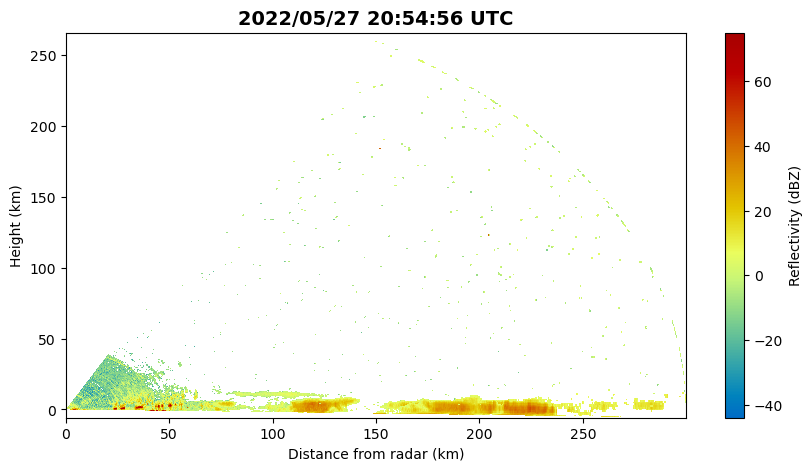

In [91]:
# 1. Setup for RHI data
Data_Directory, FileList = GetDataDirectory(Campaign, Downloaded_File, RadarType="RHI")

# 2. Create object
radar_rhi = RadarScan_RHI(Data_Directory, FileList, index=0)
radar_rhi.summary()

# Reflectivity
radar_rhi.plot_reflectivity(cmap_reflectivity=cmap_reflectivity)

# # Velocity
# radar_rhi.plot_velocity(cmap_velocity=cmap_velocity)
